In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv('/kaggle/input/datasets/belbino/us-tariff-and-trade-war-impact-dataset-2018-present/market_reaction.csv')
df['date'] = pd.to_datetime(df['date'])

# Step 1 - EDA

In [2]:
df

,date,sp500,shanghai_composite,dxy,usd_cny,crude_oil_wti,steel_futures,aluminum_futures,soybeans
0,2020-01-02,3257.850098,3085.197998,96.849998,0.143633,61.180000,587.0,1812.50,944.25
1,2020-01-03,3234.850098,3083.785889,96.839996,0.143608,63.049999,590.0,1830.00,930.50
2,2020-01-06,3246.280029,3083.407959,96.669998,0.143585,63.270000,586.0,1842.00,932.75
3,2020-01-07,3237.179932,3104.802002,96.980003,0.143379,62.700001,591.0,1822.00,935.00
4,2020-01-08,3253.050049,3066.893066,97.300003,0.144001,59.610001,581.0,1802.75,938.25
...,...,...,...,...,...,...,...,...,...
1573,2026-04-08,6782.810059,3994.998047,99.129997,0.145843,94.410004,1046.0,3374.25,1162.00
1574,2026-04-09,6824.660156,3966.170898,98.820000,0.146441,97.870003,1046.0,3373.75,1165.25
1575,2026-04-10,6816.890137,3986.225098,98.650002,0.146383,96.570000,1046.0,3429.75,1175.75
1576,2026-04-13,6886.240234,3988.558105,98.370003,0.146460,99.080002,1046.0,3582.00,1162.25


In [3]:
print(f"Total number of rows : {df.shape[0]}")
print(f"Total number of columns : {df.shape[1]}")

Total number of rows : 1578
Total number of columns : 9


In [4]:
df.dtypes

date                  datetime64[ns]
sp500                        float64
shanghai_composite           float64
dxy                          float64
usd_cny                      float64
crude_oil_wti                float64
steel_futures                float64
aluminum_futures             float64
soybeans                     float64
dtype: object

In [5]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
date,1578,2023-02-19 15:52:41.977186048,2020-01-02 00:00:00,2021-07-27 06:00:00,2023-02-19 00:00:00,2024-09-15 06:00:00,2026-04-14 00:00:00,NaN
sp500,1578.0,4682.781096,2237.399902,3924.55249,4411.72998,5570.245117,6978.600098,1104.954543
shanghai_composite,1466.0,3317.799451,2660.169922,3085.082458,3286.652466,3492.902527,4182.59082,312.237335
dxy,1578.0,100.047554,89.440002,96.297501,100.029999,104.150002,114.110001,5.372601
usd_cny,1577.0,0.144789,0.136054,0.139311,0.142594,0.149573,0.158519,0.006637
crude_oil_wti,1578.0,70.220254,-37.630001,61.5,71.610001,80.517498,123.699997,18.695126
steel_futures,1577.0,953.89981,447.0,705.0,862.0,1086.0,1945.0,357.832241
aluminum_futures,1578.0,2392.9173,1452.0,2182.3125,2397.125,2597.5,3873.0,426.116637
soybeans,1578.0,1233.369297,821.75,1029.0,1209.375,1427.6875,1769.0,236.291261


In [6]:
print("Percentage of null values for each fields:")
(df.isnull().sum()/(len(df)))*100

Percentage of null values for each fields:


date                  0.000000
sp500                 0.000000
shanghai_composite    7.097592
dxy                   0.000000
usd_cny               0.063371
crude_oil_wti         0.000000
steel_futures         0.063371
aluminum_futures      0.000000
soybeans              0.000000
dtype: float64

Some markets do have null values. 

## Monthly market average

In [7]:
df.set_index("date", inplace=True)
df_monthly = df.resample(rule = 'MS').mean()['sp500'] # MS - Month Start is rule
df_monthly_roll = df_monthly.rolling(window=3).mean()
df_monthly_expanding = df_monthly.expanding(min_periods=3).mean()


### Data does not seem to look stationary.

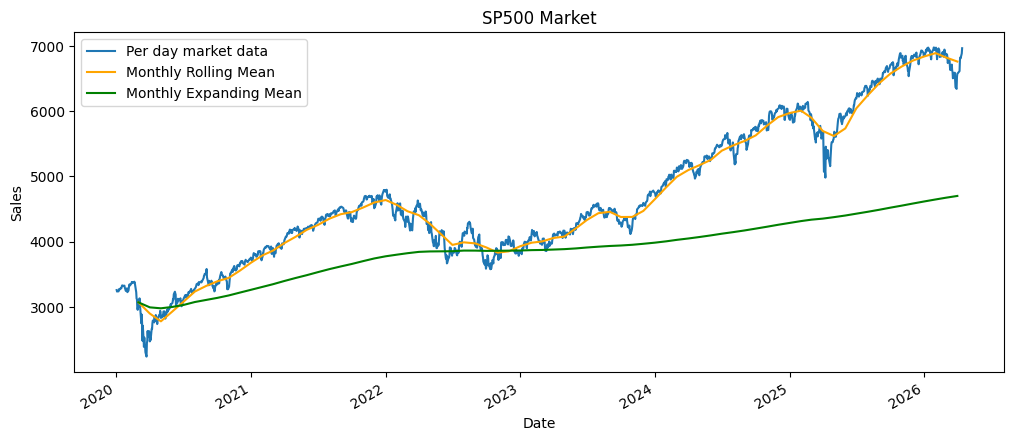

In [8]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(12, 5))

df['sp500'].plot(ax=ax, label='Per day market data')
df_monthly_roll.plot(ax=ax, label='Monthly Rolling Mean', color='orange')
df_monthly_expanding.plot(ax=ax, label='Monthly Expanding Mean', color='green')
# Set labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('SP500 Market')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')
plt.show()

# Step 2 - Statistical test

In [9]:
from statsmodels.tsa.filters.hp_filter import hpfilter
_, sales_trend = hpfilter(df['sp500'], lamb=229600)
df['Trend'] = sales_trend

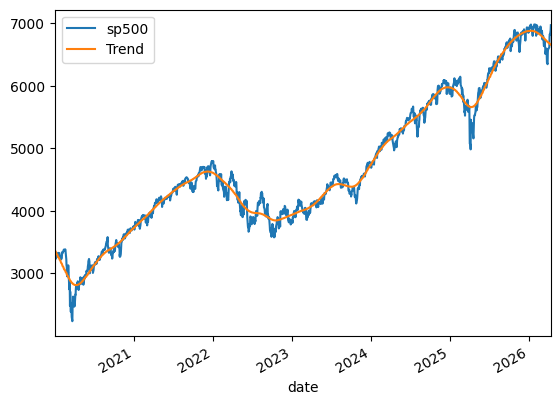

In [10]:
df[['sp500', 'Trend']].plot().autoscale(axis='x', tight=True)

In [11]:
from statsmodels.tsa.stattools import adfuller,kpss,coint,bds,q_stat,grangercausalitytests,levinson_durbin

### Augmented Dickey-Fuller

ADF determines whether a series is stationary. 


In [12]:
print('Augmented Dickey-Fuller Test')
adf_test = adfuller(df['sp500'],autolag='AIC')

dfout = pd.Series(adf_test[0:4],index=['ADF test statistic','p-value','# lags used','# observations'])

for key,val in adf_test[4].items():
    dfout[f'critical value ({key})']=val
print(dfout)

Augmented Dickey-Fuller Test
ADF test statistic        -0.091677
p-value                    0.950261
# lags used                9.000000
# observations          1568.000000
critical value (1%)       -3.434527
critical value (5%)       -2.863385
critical value (10%)      -2.567752
dtype: float64


Very high p-value at 0.94 so we fail to reject the null hypothesis, and decide that our dataset is not stationary.

In [13]:
print('Augmented Dickey-Fuller Test')
adf_test = adfuller(df['sp500'].diff(1).dropna(),autolag='AIC')

dfout = pd.Series(adf_test[0:4],index=['ADF test statistic','p-value','# lags used','# observations'])

for key,val in adf_test[4].items():
    dfout[f'critical value ({key})']=val
print(dfout)

Augmented Dickey-Fuller Test
ADF test statistic     -1.287151e+01
p-value                 4.868036e-24
# lags used             8.000000e+00
# observations          1.568000e+03
critical value (1%)    -3.434527e+00
critical value (5%)    -2.863385e+00
critical value (10%)   -2.567752e+00
dtype: float64


When differencing the data by a factor of 1, the p-value is low, providing strong evidence to reject the null hypothesis. Therefore, when using ARIMA forecasting, it is necessary to difference the data.

### Granger causality 

Granger causality tests whether past values of one time series (*x*) help predict future values of another (*y*), beyond its own past values contribution.

In [14]:
grangercausalitytests(df[['sp500','dxy']],maxlag=3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1078  , p=0.7427  , df_denom=1574, df_num=1
ssr based chi2 test:   chi2=0.1080  , p=0.7424  , df=1
likelihood ratio test: chi2=0.1080  , p=0.7424  , df=1
parameter F test:         F=0.1078  , p=0.7427  , df_denom=1574, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5970  , p=0.5506  , df_denom=1571, df_num=2
ssr based chi2 test:   chi2=1.1977  , p=0.5494  , df=2
likelihood ratio test: chi2=1.1973  , p=0.5496  , df=2
parameter F test:         F=0.5970  , p=0.5506  , df_denom=1571, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3198  , p=0.8110  , df_denom=1568, df_num=3
ssr based chi2 test:   chi2=0.9638  , p=0.8100  , df=3
likelihood ratio test: chi2=0.9635  , p=0.8101  , df=3
parameter F test:         F=0.3198  , p=0.8110  , df_denom=1568, df_num=3


In [15]:
grangercausalitytests(df[['sp500','crude_oil_wti']],maxlag=3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.6661  , p=0.1970  , df_denom=1574, df_num=1
ssr based chi2 test:   chi2=1.6693  , p=0.1964  , df=1
likelihood ratio test: chi2=1.6684  , p=0.1965  , df=1
parameter F test:         F=1.6661  , p=0.1970  , df_denom=1574, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.6936  , p=0.1842  , df_denom=1571, df_num=2
ssr based chi2 test:   chi2=3.3981  , p=0.1829  , df=2
likelihood ratio test: chi2=3.3944  , p=0.1832  , df=2
parameter F test:         F=1.6936  , p=0.1842  , df_denom=1571, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1240  , p=0.3381  , df_denom=1568, df_num=3
ssr based chi2 test:   chi2=3.3870  , p=0.3357  , df=3
likelihood ratio test: chi2=3.3833  , p=0.3362  , df=3
parameter F test:         F=1.1240  , p=0.3381  , df_denom=1568, df_num=3


Based on the result above, DXY and Crude Oil do not provide evidence that their series helps to predict SP500 because their p-value is high in all lags and tests.

### Time Series Decomposition

The decomposition of a time series attempts to isolate individual components from the original series.

- Trend
- Seasonality
- Error/Noise

Will be using a multiplicative model because of the overall trend is changing.

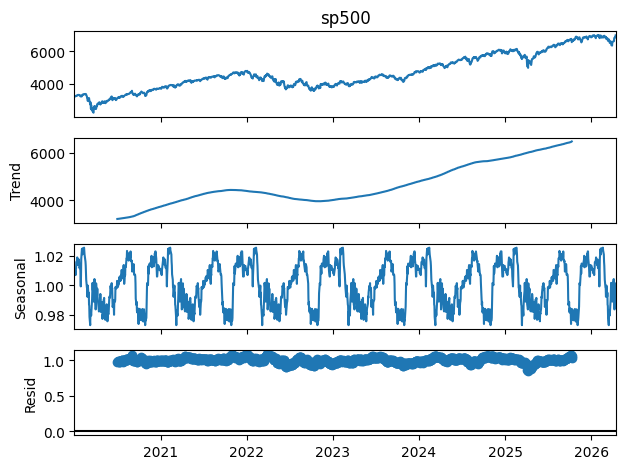

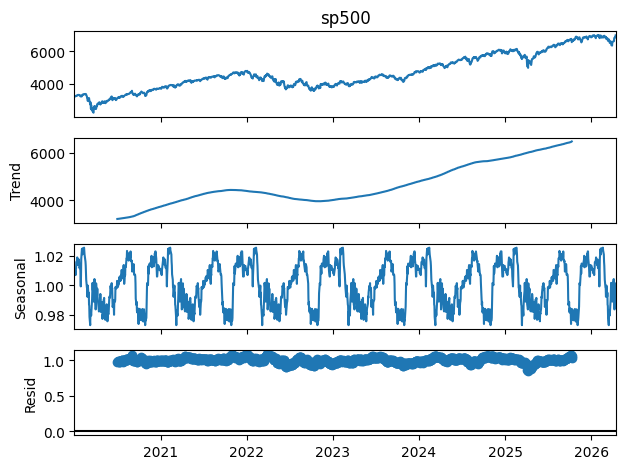

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
# 252 includes business days in a year 
seasonal_decompose(x=df['sp500'], period = 252, model='multiplicative').plot()

## Trend

* steady rise from 2020 → 2021
* dip around 2022
* strong recovery into 2024–2026

## Seasonal
* The market has a repeating short-term pattern

# Step 3 - Smoothing

Smoothing removes random noise and short-term fluctuations, highlighting the underlying trends, cycles, and signals.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


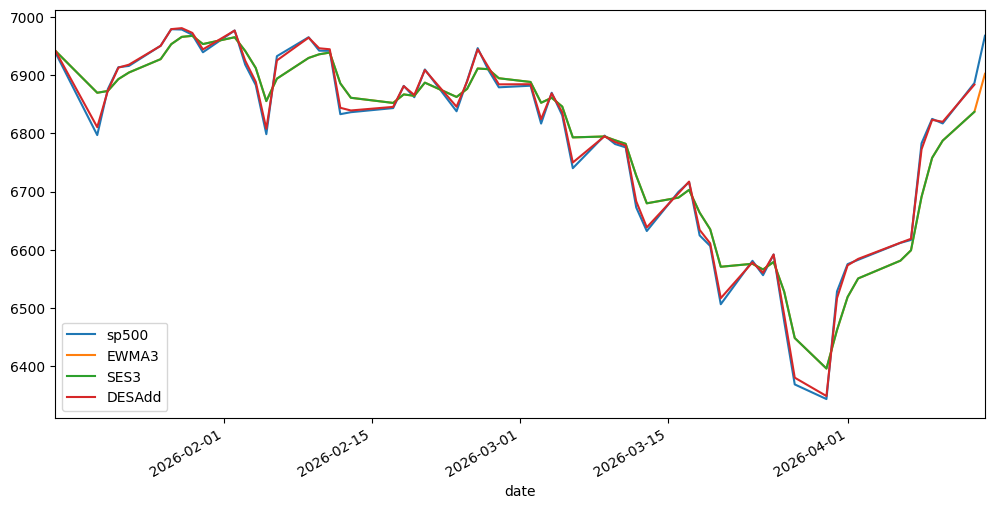

In [17]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
span = 3
#define alpha
alpha = 2/(span+1)

#exponentially weightage moving average using pandas 
df['EWMA3'] = df['sp500'].ewm(alpha=alpha, adjust=False).mean()
#Simple exponential smoothing
df['SES3'] = SimpleExpSmoothing(df['sp500']).fit(smoothing_level=alpha, 
                                                 optimized=False).fittedvalues.shift(-1)
df['DESAdd'] = ExponentialSmoothing(df['sp500'], trend='add').fit().fittedvalues.shift(-1)
df[['sp500', 'EWMA3', 'SES3', 'DESAdd']].tail(60).plot(figsize=(12, 6)).autoscale(axis='x', tight=True)


Let's stick to the original value when forecasting. Smoothing did not remove the noise strongly enough. An alternative method could have been used. 

# Step 4 - Data Preparation

In [18]:
#total length
n = len(df)
#train size
m = int(n*0.8)

train_data = df.iloc[0:m]
test_data = df.iloc[m:n]
test_dates = test_data.reset_index()['date']
print(f"Total df size {len(df)}")
print(f"Total train data size {len(train_data)}")
print(f"Total test data size {len(test_data)}")

Total df size 1578
Total train data size 1262
Total test data size 316


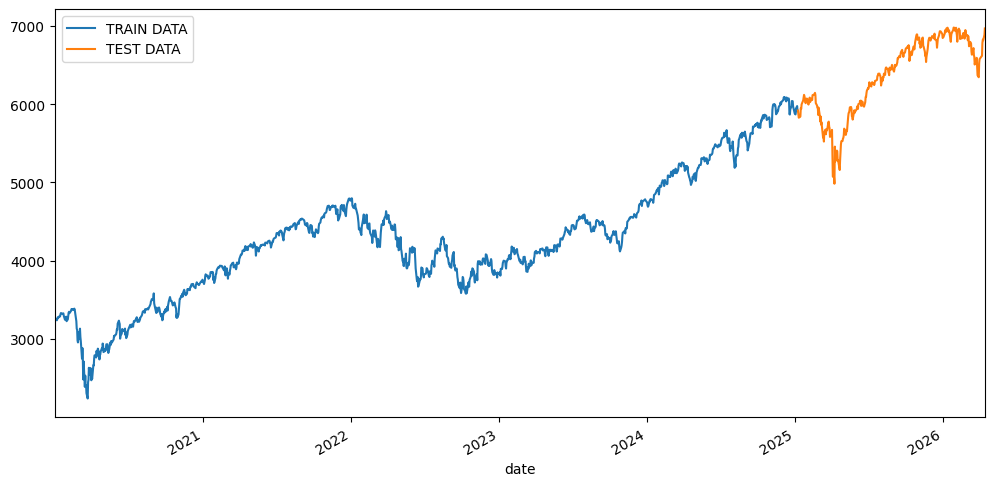

In [19]:
train_data['sp500'].plot(legend=True, label='TRAIN DATA')
test_data['sp500'].plot(legend=True, label='TEST DATA', figsize=(12, 6)).autoscale(axis='x', tight=True)

# Step 5 - Forecasting

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

fitted_model = ExponentialSmoothing(train_data['sp500'], trend='mul', seasonal='mul', seasonal_periods=12).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


In [21]:
hw_predictions = fitted_model.forecast(len(test_data)).to_frame('Holt-Winter')
hw_predictions['date'] = test_dates.tolist()
hw_predictions.set_index("date", inplace=True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [22]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.3 MB/s eta 0:00:00


In [23]:
from pmdarima import auto_arima
auto_pdq = auto_arima(train_data['sp500'], seasonal=True, m=12)
print(auto_pdq.order)

(2, 1, 2)


In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p, d, q = auto_pdq.order

model = SARIMAX(train_data['sp500'], order=(p, d, q), seasonal_order=(p, d, q, 12))
results = model.fit()

results.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              sp500   No. Observations:                 1262
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood               -6651.069
Date:                            Thu, 16 Apr 2026   AIC                          13320.138
Time:                                    14:45:49   BIC                          13366.309
Sample:                                         0   HQIC                         13337.496
                                           - 1262                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5135      0.015    100.859      0.000       1.484       1.543
ar.L2         -0.9885      0.015    -65.151      0.000      -1.018      -0.959
ma.L1         -1.5053      0.021    -72.969      0.000      -1.546      -1.465
ma.L2          0.9783      0.021     46.495      0.000       0.937       1.020
ar.S.L12      -0.9903      0.122     -8.126      0.000      -1.229      -0.751
ar.S.L24       0.0061      0.028      0.221      0.825      -0.048       0.060
ma.S.L12      -0.0049      0.657     -0.007      0.994      -1.292       1.282
ma.S.L24      -0.9951      0.706     -1.409      0.159      -2.380       0.389
sigma2      2364.4294   1593.409      1.484      0.138    -758.595    5487.454
===================================================================================
Ljung-Box (L1) (Q):                  13.28   Jarque-Bera (JB):               366.02
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.61   Skew:                            -0.37
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
start=len(train_data['sp500'])
end=len(train_data['sp500'])+len(test_data['sp500'])-1
arima_predictions = results.predict(start=start, end=end).to_frame('SARIMA')

arima_predictions['date'] = test_dates.tolist()
arima_predictions.set_index("date", inplace=True)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
from prophet import Prophet 

prophet_model = Prophet()
prophet_model.fit(train_data[['sp500']].reset_index().rename(columns = {'date':'ds', 'sp500':'y'}))

14:45:51 - cmdstanpy - INFO - Chain [1] start processing
14:45:52 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# Making predictions on the validation set
future_uni = prophet_model.make_future_dataframe(periods=len(test_data['sp500']))
forecast_uni = prophet_model.predict(future_uni)

In [28]:
forecast_uni = forecast_uni.tail(len(test_dates))
forecast_uni['date'] = test_dates.tolist()
forecast_uni = forecast_uni[['date', 'yhat']]
forecast_uni.rename(columns = {'yhat':'Prophet'}, inplace=True)
forecast_uni.set_index("date", inplace=True)

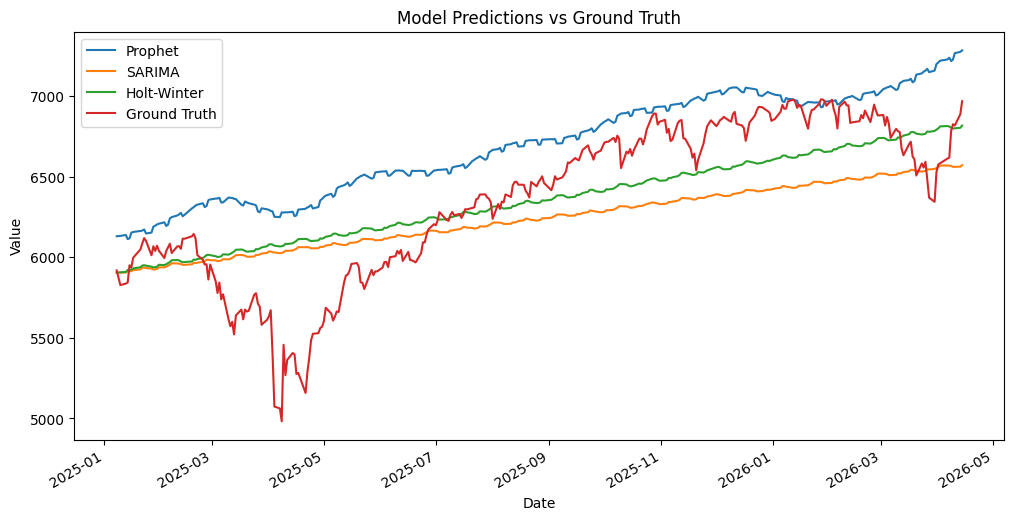

In [29]:
# Create one plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot everything on the same axis
forecast_uni.plot(ax=ax, legend=True, label='Prophet')
arima_predictions.plot(ax=ax, legend=True, label='ARIMA')
hw_predictions.plot(ax=ax, legend=True, label='Holt-Winters')
test_data['sp500'].plot(ax=ax, legend=True, label='Ground Truth')

# Optional formatting
ax.set_title("Model Predictions vs Ground Truth")
ax.set_xlabel("Date")
ax.set_ylabel("Value")

plt.show()